# Introduction
This report analyzes U.S. quarterly GDP growth rates from 2010 to 2023 using three curve-fitting and interpolation techniques implemented from scratch. The dataset consists of 20 selected quarters of seasonally adjusted annual rate real GDP growth, sourced from the U.S. Bureau of Economic Analysis. The data includes the COVID-19 pandemic quarters of 2020, which act as outliers. Three methods are compared:
1. Least Squares Linear Regression, which fits a straight line that minimizes the sum of squared residuals;
2. Polynomial Fitting (degree 4) via the normal equations, which captures nonlinear trends while still acting as an approximation rather than an exact interpolant;
3. Natural Cubic Spline Interpolation, which passes exactly through every data point using piecewise cubic polynomials that satisfy C² continuity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

quarter_labels = [
    '2010 Q1', '2011 Q1', '2012 Q1', '2013 Q1', '2014 Q1',
    '2014 Q3', '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q4',
    '2017 Q1', '2018 Q1', '2019 Q1', '2020 Q1', '2020 Q2',
    '2020 Q3', '2021 Q1', '2022 Q1', '2023 Q2', '2023 Q4'
]

gdp_growth = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
])

#Converts quarters into integers where x = 1 is defined as 2021 Q1
x = []
for value in quarter_labels:
    year, q = value.split()
    x.append((int(year) - 2010) * 4 + int(q[1]))

x = np.array(x, dtype=float)
print(x)

#Helper Functions

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
 
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
 
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]                                            # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i])                              # Main diagonal
        C[i - 1] = h[i]                                                # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i]
                       - (y[i] - y[i - 1]) / h[i - 1])                # Right-hand side vector
 
    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    b = b.copy()
    d = d.copy()
 
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
 
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
 
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
 
    return x


def evaluate_spline(x_data, y_data, M, x_eval):
    """Evaluate the natural cubic spline at a single point x_eval."""
    n = len(x_data)
    h = np.diff(x_data)
 
    i = 0
    for j in range(n - 1):
        if x_data[j] <= x_eval <= x_data[j + 1]:
            i = j
            break
 
    dx = x_eval - x_data[i]
 
    a_i = y_data[i]
    b_i = (y_data[i+1] - y_data[i]) / h[i] - h[i] * (2*M[i] + M[i+1]) / 6
    c_i = M[i] / 2
    d_i = (M[i+1] - M[i]) / (6 * h[i])
 
    return a_i + b_i*dx + c_i*dx**2 + d_i*dx**3

[ 1.  5.  9. 13. 17. 19. 22. 25. 27. 28. 29. 33. 37. 41. 42. 43. 45. 49.
 54. 56.]


In [2]:
#Creates the spline
A, B, C, D = setup_tridiagonal_matrix(x, gdp_growth)

M_interior = thomas_algorithm(A[1:], B, C[:-1], D)
M = np.zeros(len(x))
M[1:-1] = M_interior

In [3]:
y_at_knots = np.array([evaluate_spline(x, gdp_growth, M, xi) for xi in x])
interp_error = np.max(np.abs(y_at_knots - gdp_growth))
print(f"Max interpolation error at knots: {interp_error:.2e}")

# Verify C0, C1, C2 continuity at interior knots
h = np.diff(x)
max_c0_err = 0
max_c1_err = 0
max_c2_err = 0

for i in range(len(x) - 2):
    # Coefficients for segment i
    a_i = gdp_growth[i]
    b_i = (gdp_growth[i+1] - gdp_growth[i]) / h[i] - h[i] * (2*M[i] + M[i+1]) / 6
    c_i = M[i] / 2
    d_i = (M[i+1] - M[i]) / (6 * h[i])

    # Coefficients for segment i+1
    b_ip1 = (gdp_growth[i+2] - gdp_growth[i+1]) / h[i+1] - h[i+1] * (2*M[i+1] + M[i+2]) / 6
    c_ip1 = M[i+1] / 2

    hi = h[i]

    # C0: value at x_{i+1} from left vs right
    val_left  = a_i + b_i*hi + c_i*hi**2 + d_i*hi**3
    val_right = gdp_growth[i+1]
    max_c0_err = max(max_c0_err, abs(val_left - val_right))

    # C1: first derivative at x_{i+1}
    d1_left  = b_i + 2*c_i*hi + 3*d_i*hi**2
    d1_right = b_ip1
    max_c1_err = max(max_c1_err, abs(d1_left - d1_right))

    # C2: second derivative at x_{i+1}
    d2_left  = 2*c_i + 6*d_i*hi
    d2_right = 2*c_ip1
    max_c2_err = max(max_c2_err, abs(d2_left - d2_right))

"""
The continuity errors are minimal and are just floating point errors. 
This is good and means our code is working properly.
"""
print(f"  Max C0 error: {max_c0_err:.2e}")
print(f"  Max C1 error: {max_c1_err:.2e}")
print(f"  Max C2 error: {max_c2_err:.2e}")

Max interpolation error at knots: 1.15e-14
  Max C0 error: 1.15e-14
  Max C1 error: 7.11e-15
  Max C2 error: 2.84e-14


# A1 Discussion
Given n=20 data points we construct n-1(19) cubic polynomials of the form:
 $$S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3, \quad i = 1, \ldots, 19$$
Each segment has 4 coefficients, giving 76 unknowns
We use the following continuity conditions:
1. $S_i(x_{i+1}) = S_{i+1}(x_{i+1})$ (18 equations)
2. $S_i'(x_{i+1}) = S_{i+1}'(x_{i+1})$ (18 equations)
3. $S_i''(x_{i+1}) = S_{i+1}''(x_{i+1})$ (18 equations)

Interpolation condition:
$S_i(x_i) = y_i$ for $i = 1, ... 19$ and $S_19(x_20) = y_20$ (20 equations)
Natural Boundary Conditions:
    $S_1''(x_1) = 0$ and $S_{19}''(x_{20}) = 0$ (2 equations)
This yields 76 total equations making the system uniquely determined. By introducing the second-derivative values $M_i = S_i''(x_i)$ at each knot, the C² continuity conditions reduce to a single tridiagonal system of size $(n-2) \times (n-2) = 18 \times 18$ for the interior $M$ values, with the natural boundary conditions setting $M_0 = M_{19} = 0$. This tridiagonal system is solved efficiently using the Thomas algorithm.

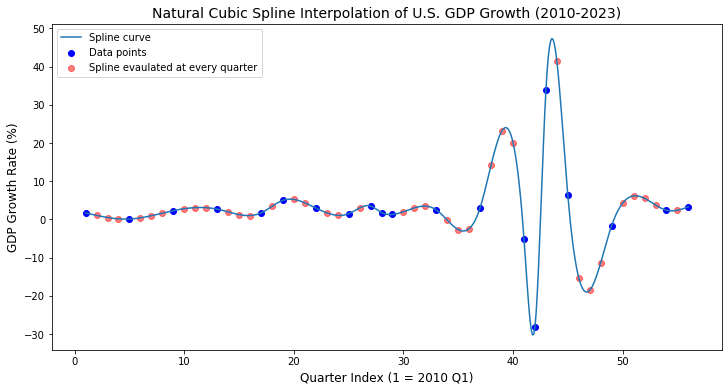

In [4]:
#Adding "fine" points to graph the curve
x_fine = np.linspace(x[0], x[-1], 500)
y_spline_fine = np.array([evaluate_spline(x, gdp_growth, M, xi) for xi in x_fine])

#All points in the quarter dataset, not just the subset we used to fit our spline
x_all = np.arange(1, int(x[-1]) + 1, dtype=float)
#Remove the duplicate points to make the graph more clear
x_all = np.setdiff1d(x_all, x)
y_spline_all = np.array([evaluate_spline(x, gdp_growth, M, xi) for xi in x_all])

#Cubic spline curve
plt.figure(figsize=(12,6))
plt.plot(x_fine, y_spline_fine, label = "Spline curve")
#Raw points
plt.scatter(x,gdp_growth, color = 'blue', label = "Data points")
#Spline evaluation of all quarter points

plt.scatter(x_all,y_spline_all, color = 'red', alpha=0.5, label = "Spline evaulated at every quarter")
plt.legend()
plt.xlabel('Quarter Index (1 = 2010 Q1)', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.title('Natural Cubic Spline Interpolation of U.S. GDP Growth (2010-2023)', fontsize=14)
plt.show()

# A2 Discussion
The interpolant is visually smooth which is expected because of $C^2$ continuity. Not near the COVID quarters, the splie gives very reasonable outputs. However, near the COVID quarters the spline gives some oscilations(bewteen 33-37 and 49-54) caused because the spline is forced to splice through the outlier points. This combinted with forcing $C^2$ continuity causes nearby quarters to have curves that are unreasonable. 

# A3 Discussion

The Runge phenomenon refers to the tendency of high-degree polynomial interpolants to develop large oscillations near the edges of the interpolation interval. While cubic splines use low degree polynomials, something similar happens when data points near each other have dramatically different values. The COVID-19 quarters (-28.1% and +33.8%) are separated by only one quarter, forcing the spline to pass through ~62 percentage points in a single segment. This causes errors near the outlier because of the C2 continuity conditions.

Exact interpolation guarantees the curve passes through every data point, including outliers. This is helpful when data is precise, but when extreme values occur, forcing the curve through outliers them harms the fit elsewhere. Outliers can make the system more "ill-conditioned" where small input errors lead to large errors overall.
 
Smoothing splines introduce a regularization parameter that penalizes curvature (minimizing the integral of the squared second derivative). By allowing the curve to deviate slightly from extreme data points, smoothing splines avoid the wild oscillations seen near the COVID quarters. This makes them a good choice when the data contains outliers or measurement noise.

Weighted least squares allows the analyst to assign lower weight to known outlier quarters, reducing their influence on the fitted curve while still incorporating all non-outlier data. This is conceptually simpler than smoothing splines and makes the analyst's judgment about which points are "typical" explicit.


In [5]:
#Helper functions for part b
def poly_fit(x, y, degree):
    """
    Fits a polynomial using the normal equations
    Builds the Vandermonde matrix A, forms the normal equations,
    and solves using numpy.linalg.solve.
    """
    n = len(x)
    
    # Build Vandermonde matrix: A[i,j] = x_i^j
    A = np.zeros((n, degree + 1))
    for j in range(degree + 1):
        A[:, j] = x ** j
    
    # Normal equations: (A^T A) c = A^T y
    ATA = A.T @ A
    ATy = A.T @ y
    
    # Check condition number
    cond_A = np.linalg.cond(A)
    cond_ATA = np.linalg.cond(ATA)
    print(f"  cond(A) for degree {degree}: {cond_A:.2e}")
    print(f"  cond(A^T A) for degree {degree}: {cond_ATA:.2e}")
    if cond_A > 1e12:
        print("  WARNING: cond(A) > 10^12 — results may be unreliable.")
    
    c = np.linalg.solve(ATA, ATy)
    return c, A

def poly_eval(c, x_eval):
    """
    Evaluate polynomial with coefficients c at points x_eval.
    C should have the coefficients in ascending order
    """
    x_eval = np.atleast_1d(x_eval)
    y_eval = np.zeros_like(x_eval)
    for j, coeff in enumerate(c):
        y_eval += coeff * x_eval**j
    return y_eval


def compute_rmse(y_actual, y_predicted):
    return np.sqrt(np.mean((y_actual - y_predicted)**2))

  cond(A) for degree 4: 1.82e+07
  cond(A^T A) for degree 4: 3.31e+14
RMSE for poly fit: 10.0314 %


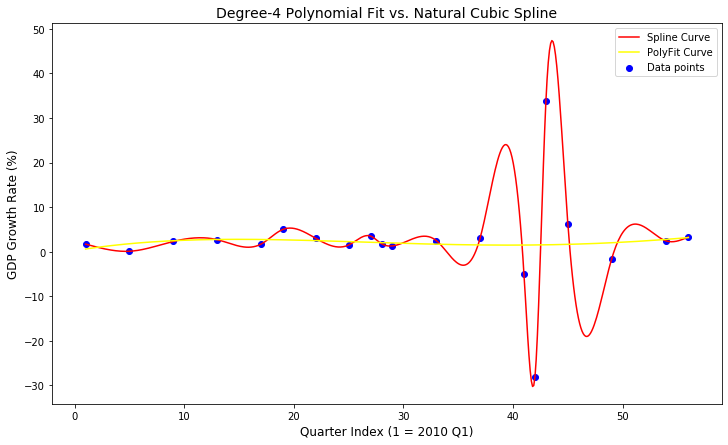

In [6]:
c4, A4 = poly_fit(x, gdp_growth, 4)

y_poly_fine = poly_eval(c4, x_fine)
y_poly_data = poly_eval(c4, x)

rmse_poly = compute_rmse(gdp_growth, y_poly_data)

print(f"RMSE for poly fit: {rmse_poly:.4f} %")

plt.figure(figsize=(12, 7))
plt.plot(x_fine, y_spline_fine, color = "red", label = "Spline Curve")
plt.plot(x_fine, y_poly_fine, color = "yellow", label = "PolyFit Curve")
plt.scatter(x, gdp_growth, color='blue',label='Data points')
plt.legend()
plt.xlabel('Quarter Index (1 = 2010 Q1)', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.title('Degree-4 Polynomial Fit vs. Natural Cubic Spline', fontsize=14)
plt.show()


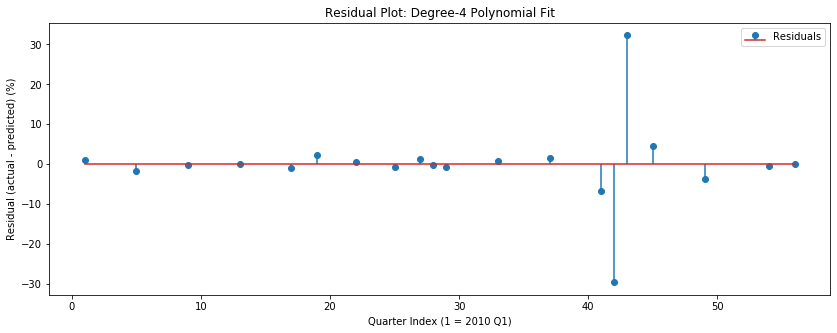

Max absolute residual: 32.26 %
Mean residual: -0.0000 % (should be near zero)


In [7]:
# ── Residual plot for degree-4 polynomial ─────────────────────
residuals_poly = gdp_growth - y_poly_data

plt.figure(figsize=(14, 5))
plt.stem(x, residuals_poly, label='Residuals', use_line_collection=True)
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('Residual (actual - predicted) (%)')
plt.title('Residual Plot: Degree-4 Polynomial Fit')
plt.legend()
plt.show()

print(f"Max absolute residual: {np.max(np.abs(residuals_poly)):.2f} %")
print(f"Mean residual: {np.mean(residuals_poly):.4f} % (should be near zero)")

# B1 Discussion

The spline curve passes through every data point, achieving an RMSE of 0%, while the degree-4 polynomial has an RMSE of approximately 10.03. The polynomial captures the trend of the data but it "smooths" over the extreme values. The residual plot shows that the largest residual is 32.26%, occurring at the COVID quarters where the polynomial cannot track the sharp dip and recovery. The spline  reproduces these outliers but, as discussed in Part A, suffers from fake oscillations in the surrounding segments. There is a tradeoff of approximation and interpolation, the more you treat each point as a "ground truth" the better you become at interpolation because you can reproduce specific points but the less you capture the overall trend due to outlier sensitivity.

It is also worth noting that while $\text{cond}(A) \approx 1.82 \times 10^7$ is acceptable, $\text{cond}(A^T A) \approx 3.31 \times 10^{14}$ is very large, illustrating the well-known problem that forming the normal equations squares the condition number. For higher-degree polynomials, QR decomposition would be more numerically stable. However, the assignment says as long as the condition of A is less than $10^{12}$ it is okay so I continued to use the normal equations.

  cond(A) for degree 1: 6.00e+01
  cond(A^T A) for degree 1: 3.61e+03
Slope: -0.0019
RMSE for linear fit excluding COVID): 1.4432 %


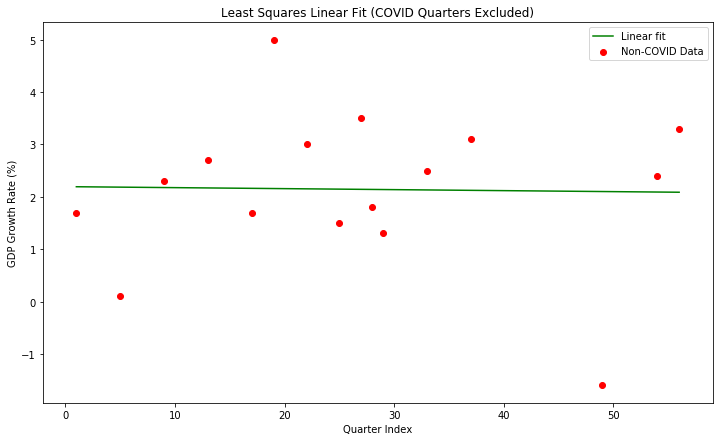

In [11]:
#Remove covid dates frm our dataset
covid_labels = {'2020 Q1', '2020 Q2', '2020 Q3', '2021 Q1'}
mask = np.array([ql not in covid_labels for ql in quarter_labels])

x_no_covid = x[mask]
y_no_covid = gdp_growth[mask]

#Note: these rewrites our first poly fit
c1, A1 = poly_fit(x_no_covid, y_no_covid, degree=1)

print(f"Slope: {c1[1]:.4f}")

y_linear_fine = poly_eval(c1, x_fine)
y_linear_data = poly_eval(c1, x_no_covid)
rmse_linear = compute_rmse(y_no_covid, y_linear_data)
print(f"RMSE for linear fit excluding COVID): {rmse_linear:.4f} %")

plt.figure(figsize=(12, 7))
plt.plot(x_fine, y_linear_fine, color = 'green', label='Linear fit')
plt.scatter(x_no_covid, y_no_covid, color='red', label='Non-COVID Data')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.title('Least Squares Linear Fit (COVID Quarters Excluded)')
plt.legend()
plt.show()

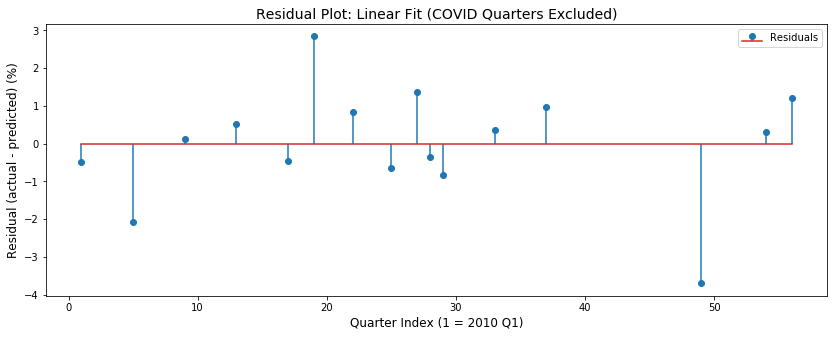

Max absolute residual: 3.70 %
Mean residual: 0.0000 %


In [9]:
# ── Residual plot for linear fit ──────────────────────────────
residuals_linear = y_no_covid - y_linear_data

plt.figure(figsize=(14, 5))
plt.stem(x_no_covid, residuals_linear, label='Residuals', use_line_collection=True)
plt.xlabel('Quarter Index (1 = 2010 Q1)', fontsize=12)
plt.ylabel('Residual (actual - predicted) (%)', fontsize=12)
plt.title('Residual Plot: Linear Fit (COVID Quarters Excluded)', fontsize=14)
plt.legend()
plt.show()

print(f"Max absolute residual: {np.max(np.abs(residuals_linear)):.2f} %")
print(f"Mean residual: {np.mean(residuals_linear):.4f} %")

# B2 Discussion
The linear fit had a near-zero negative slope (-0.0019%/quarter), suggesting that, ignoring COVID, gdp growth was pretty stable between 2010 and 2023. The linear model implies a near constant rate of change for GDP growth. Over a long enough time window, this is reasonable. However, over short intervals this is not a valid approximation, because growth rates are not stable in the short term, so this will not work if you are trying to see GDP growth in the short term.
Linear fit makes the assumptions that that the residuals have constant variance, error is normally distributed and observations are independent. These are not entirely true but the exclusion of outlier data makes these assumptions mostly true.
The residuals confirm that the linear fit is a reasonable approximation for this data, ignoring outliers, because there is no strong correlation between the residuals.

Method Comparison Summary
Method                                   RMSE      
Natural Cubic Spline (all data)          0.000000  
Degree-4 Polynomial (all data)           10.0314   
Degree-4 Polynomial (excl. COVID)        1.3752    
Linear Fit (excl. COVID)                 1.4432    

Condition number of Vandermonde A (degree 4): 1.82e+07


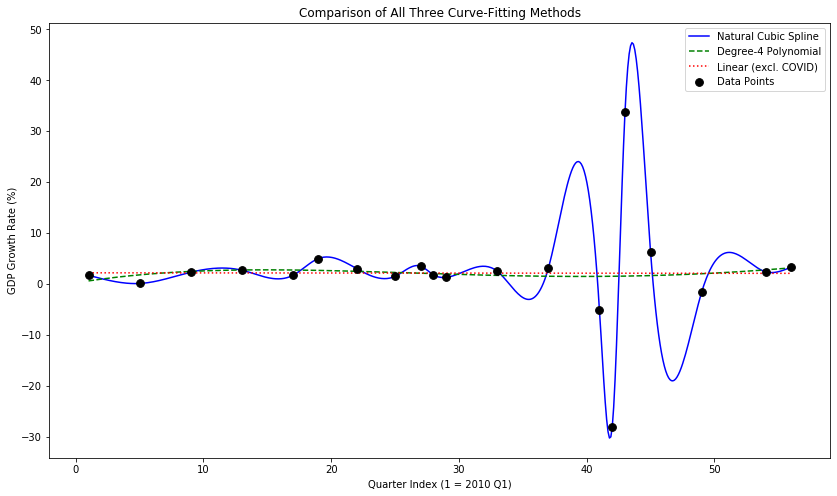

In [10]:
rmse_spline = compute_rmse(gdp_growth, y_at_knots)
rmse_poly_no_covid = compute_rmse(y_no_covid, poly_eval(c4, x_no_covid))

print("Method Comparison Summary")
print(f"{'Method':<40} {'RMSE':<10}")
print(f"{'Natural Cubic Spline (all data)':<40} {rmse_spline:<10.6f}")
print(f"{'Degree-4 Polynomial (all data)':<40} {rmse_poly:<10.4f}")
print(f"{'Degree-4 Polynomial (excl. COVID)':<40} {rmse_poly_no_covid:<10.4f}")
print(f"{'Linear Fit (excl. COVID)':<40} {rmse_linear:<10.4f}")

cond_A4 = np.linalg.cond(A4)
print(f"\nCondition number of Vandermonde A (degree 4): {cond_A4:.2e}")

plt.figure(figsize=(14, 8))
plt.plot(x_fine, y_spline_fine, 'b-', label='Natural Cubic Spline')
plt.plot(x_fine, y_poly_fine, 'g--', label='Degree-4 Polynomial')
plt.plot(x_fine, y_linear_fine, 'r:', label=f'Linear (excl. COVID)')
plt.scatter(x, gdp_growth, color='black', s=60, zorder=5, label='Data Points')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)',)
plt.title('Comparison of All Three Curve-Fitting Methods')
plt.legend()
plt.show()

# C Discussion
For a policymaker who needs to interpolate GDP values I would recommend a cubic spline. The cubic spline is smooth, as it has C2 continuity. This stops steep/abrupt disruptions and leads to economically plausible data. Cubic spline is forced to be accurate on the points it is fitted to, this creates more accuracy for interpolation. One thing to consider though is sensitivity to outliers, spline outputs may not be very accurate near the outlier values caused by COVID, particularly the osciliations before and after COVID. However since cubic spline is constructed piecewise, it accounts for the fact that the trend is different near COVID and far away from COVID whereas polyfit assumes that the trend is equal for all quarters. A quantitative way to to justify this is that the RMSE of a cubic spline is 0%(basically by definition) compared to the polynomial RMSE of ~10%, this is because it is forced to go through each point but this makes it more useful for interpolation. One caveat however, is that if the policymaker specifically needs to interpolate near the COVID outliers, the spline's oscillatory behavior in that region could produce bad estimates. In that case, a smoothing spline or weighted least squares approach would be more accurate, as these methods allow controlled deviation from extreme data points while still providing a smooth interpolant. Overall, the cubic spline would be more accurate than polynomial fitting for interpolation.

# Conclusion
This project compared three curve-fitting methods applied to U.S. GDP growth data from 2010 to 2023. For interpolation the natural cubic spline is the clear choice, offering exact reproduction of data values with $C^2$ smoothness and localized sensitivity to outliers. For trend analysis the degree-4 polynomial and the linear fit are more appropriate, as they smooth over quarter-to-quarter noise and extreme outlier values. The linear fit (excluding COVID) revealed a near-zero slope, confirming that average GDP growth was approximately stable over this period, while the degree-4 polynomial captured the broad dip-and-recovery shape of the COVID era.

The most important lesson from this analysis is that no single method is best for all purposes. Interpolation and approximation serve different goals, and the presence of outliers — particularly the extreme COVID-19 quarters — exposes the limitations of each approach. Exact interpolants like cubic splines suffer from oscillations near outliers and global approximations like polynomials distort the entire curve when outliers are present and assume that all quarters follow the same trend. Understanding these trade-offs, and selecting methods accordingly, is important for producing reliable and interpretable results.